<hr style="border:1px solid #808080">                                                                                                                   </hr>
<h1 style="color:#0176DE;text-align:center;margin:0;padding-top:0;"> <b>Tutorial: usando quiver</b>                                                                           </h1>
<h1 style="color:#0176DE;text-align:center;margin:0;padding-top:0;"> <b>IBM2020 Introducción a la Biomecánica</b>                                                                           </h1>
<p style=padding:0;margin:0>
<h3 style="color:#c1ccdb;text-align:center;margin:0;padding:0;"> Profesor - <span style="color:#dbdbdb;text-align:center;"><b>Daniel Hurtado</b></span></h3>
<h3 style="color:#c1ccdb;text-align:center;margin:0;padding:0;">Ayudantes - <span style="color:#dbdbdb;text-align:center;"><b>Vicente Zúñiga, Clio Kipreos, Catalina Neira</b></span></h3> 
</p>
<h4 style="color:#dbdbdb;text-align:center;margin:0;padding:0;">Instituto de Ingeniería Biológica y Médica<br>Escuela de Ingeniería<br>  Pontificia Universidad Católica de Chile <br></h4>
Adaptado del tutorial de Pablo Zurita.
<hr style="border:1px solid #808080">  


# Comando `quiver` para graficar campos vectoriales

#### Adaptado de un tutorial para IBM/ICE2020 del 2023, hecho originalmente por Pablo Zurita.

Para el gráfico de campos vectoriales, podemos usar el comando `quiver` de `matplotlib`. Consideremos, por ejemplo, el campo

$$
    \mathbf{f}(\mathbf{x}) = \begin{pmatrix} \frac{\sqrt{x_{1}}}{2} \\ x_{2} \end{pmatrix}
$$

y supongamos que este campo actúa sobre una región $\Omega = [0, 5] \times [-1, 1]$, pero queremos graficar su efecto solo en la frontera derecha de la región.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Creamos una grilla de $\Omega$.

In [2]:
x = np.linspace(0, 5, 100)
y = np.linspace(-0.5, 0.5, 400)

xx, yy = np.meshgrid(x, y)

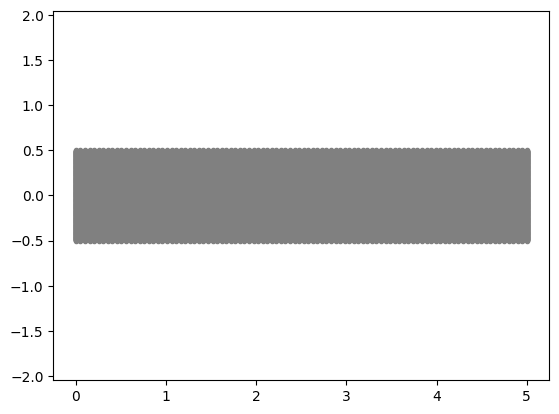

In [45]:
plt.figure()
plt.plot(xx, yy, '.', color='gray')
plt.axis('equal')
plt.show()

La grilla es suficientemente _fina_ como para que el bloque se vea continuo. Qué tan fina es una grilla o una discretización se refiere al tamaño de los segmentos discretos: mientras más pequeños, más fina es. Es importante saber que mientras más fina sea la discretización, mayor resolución tendrán los campos graficados sobre ella.

¿Qué pasa si queremos graficar $\mathbf{f}$? Por supuesto, necesitamos un arreglo que contenga los valores de $\mathbf{f}$ que nos interesa graficar. Dijimos que queríamos el borde derecho de la región, así que... vamos a obtener una **grilla de la región de interés**. Por supuesto, podríamos obtener esto **seleccionando valores de la grilla original**, pero para efectos de este ejemplo, vamos a generar una nueva.

In [4]:
y_reshape = np.linspace(-0.5, 0.5, 5)
x_reshape = 5

xx_right, yy_right = np.meshgrid(x_reshape, y_reshape)

Ahora, necesitamos un arreglo que represente nuestro campo vectorial sobre la región de interés. Tomamos, entonces,

In [40]:
def f(x, y):
    return np.array([np.sqrt(x)/2, y])

ff = f(xx_right, yy_right)
ff_norm = np.linalg.norm(ff, axis=0)

print(ff.shape)
print(ff_norm.shape)


(2, 5, 1)
(5, 1)


Por último, utilizamos la función `quiver` para graficar. Notemos que, como la grilla sobre la que estamos graficando es más gruesa, se verán menos vectores. Graficaremos en la misma `figure` a la región, para verlas juntas. Además, ajustaremos los ejes del gráfico para, efectivamente, hacer un _zoom_ a la región de interés.

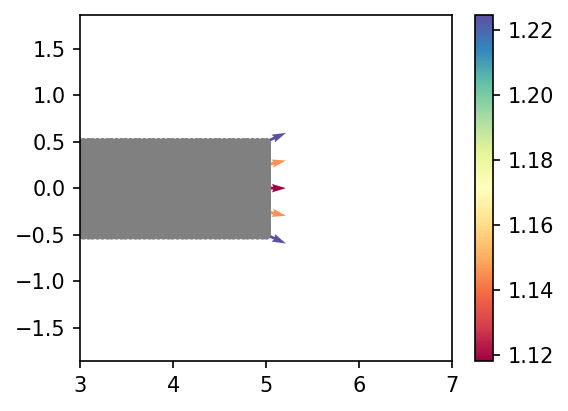

In [44]:
fig, ax = plt.subplots(figsize=(4,3), dpi=150)

ax.plot(xx, yy, '.', color='gray')
a0 = ax.quiver(xx_right, yy_right,
               ff[0], ff[1],
               ff_norm, cmap='Spectral')
fig.colorbar(a0)
ax.axis('equal')
ax.set_xlim(3, 7)
plt.show()